<a href="https://colab.research.google.com/github/mwangimarie43-art/100-days-ai-journey/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using the project problem identified in Week 1:


Briefly restate your project problem and intended AI/ML outcome. (Add this as a markdown in the Colab notebook that you will create for your assignment)

Identify the data you would need.
Get the dataset for your project. If you cannot find data directly related to your project, use a relevant dataset from Kaggle, Zindi, Hugging Face, or another appropriate source.

Import the dataset into your Colab notebook and display a small portion of it.

Identify the potential inputs (features) and output (target) for your project.

Draw and briefly explain your proposed ML workflow. (Do it as a markdown using any illustration that works for you.)

Save the notebook in your course-project GitHub repository and submit the notebook link on Google Classroom.
Please remember to click 'Turn in' to complete the assignment submission process.

Predicting localized drought/flood risk for a farming region one season ahead, using ENSO state and historical regional climate data, to give farmers/local offices a decision-support signal (risk level + confidence) rather than a precise forecast.

In [19]:
import pandas as pd

temp = pd.read_csv('temp.csv')
pest = pd.read_csv('pesticides.csv').rename(columns={'Area':'country','Year':'year','Value':'pesticides_tonnes'})
rain = pd.read_csv('rainfall.csv')
rain.columns = rain.columns.str.strip()
rain = rain.rename(columns={'Area':'country','Year':'year','average_rain_fall_mm_per_year':'rainfall_mm'})
yld = pd.read_csv('yield.csv').rename(columns={'Area':'country','Year':'year','Item':'crop','Value':'yield_hg_ha'})

df = yld[['country','crop','year','yield_hg_ha']].merge(temp[['country','year','avg_temp']], on=['country','year'])
df = df.merge(pest[['country','year','pesticides_tonnes']], on=['country','year'])
df = df.merge(rain[['country','year','rainfall_mm']], on=['country','year'])
df.head()



,country,crop,year,yield_hg_ha,avg_temp,pesticides_tonnes,rainfall_mm
0,Albania,Maize,1990.0,36613.0,16.37,121.0,1485
1,Albania,Maize,1991.0,29068.0,15.36,121.0,1485
2,Albania,Maize,1992.0,24876.0,16.06,121.0,1485
3,Albania,Maize,1993.0,24185.0,16.05,121.0,1485
4,Albania,Maize,1994.0,25848.0,16.96,201.0,1485


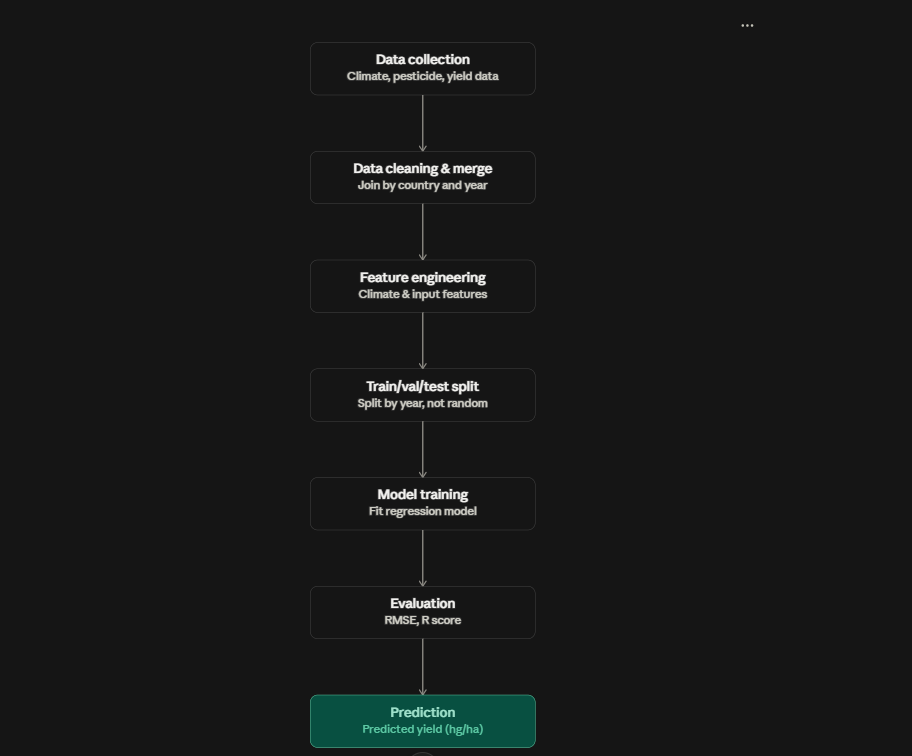


**1. Data collection**
Four separate datasets — `temp.csv` (avg_temp by country/year), `rainfall.csv` (avg rainfall by country/year), `pesticides.csv` (pesticide use in tonnes by country/year), and `yield.csv` (crop yield in hg/ha by country/crop/year) — are loaded as the raw inputs. These come from different sources (climate records, agricultural input records, FAO-style production statistics) and don't share a single file format, which is why the next step matters.

**2. Data cleaning & merge**
Each file is standardized to common column names (`country`, `year`) and joined together using an inner merge on `country` + `year`. Since `yield.csv` also has a `crop` column (multiple crops per country/year), the merge naturally produces one row per country-crop-year combination, each carrying that year's climate and input values alongside the yield for that specific crop. Missing values (e.g., years where a country has no temperature reading) get dropped or flagged at this stage, since an inner merge already excludes non-overlapping rows — worth checking how much data that drops.

**3. Feature engineering**
Raw columns become model-ready inputs here. At minimum: `avg_temp`, `rainfall_mm`, and `pesticides_tonnes` as numeric features, plus `country` and `crop` encoded as categorical features (e.g., one-hot encoding or target encoding, since there are 101 countries and 10 crops). You could also add derived features like a temperature anomaly (deviation from that country's historical average) or a lagged yield (previous year's yield for the same country/crop), which often helps since yield tends to trend gradually rather than jump randomly.

**4. Train/val/test split**
Because this is time-series-like data (years), the split should be done by year rather than randomly shuffling rows — e.g., train on 1990–2010, validate on 2011–2013, test on 2014–2016. Random splitting would let the model "see" future years during training, which inflates performance and isn't realistic. If scoping to Kenya only, be aware the usable year range per crop is narrower (23 years here), so the split needs to leave enough data in each set to be meaningful.

**5. Model training**
Since the target (`yield_hg_ha`) is continuous, this is a regression task. A reasonable starting point is a simple model like linear regression (to establish a baseline and see which features matter) or a tree-based model like Random Forest Regressor or Gradient Boosting (better at capturing non-linear relationships between climate and yield, and handles categorical features like country/crop more naturally).

**6. Evaluation**
RMSE (root mean squared error) gives an error in the same units as yield (hg/ha), making it interpretable — "the model is off by about X hg/ha on average." R² tells you what proportion of the variation in yield the model explains. Both should be checked on the held-out test set, not just training data, to see if the model generalizes rather than just memorizing patterns from specific countries/years.

**7. Prediction**
The trained model takes a new input (a country, crop, year's climate/pesticide values) and outputs a predicted yield in hg/ha — which is the deliverable the assignment is ultimately building toward.

